# Mule Account Detection — Exploratory Data Analysis
**RBI Innovation Hub**

**Author:** Suhaib Khan  
**Dataset:** 7.4M banking transactions | 40K accounts | Jul 2020 – Jun 2025  
**Objective:** Identify behavioral patterns distinguishing mule accounts from legitimate ones across 12 RBI-defined suspicious activity categories.

---

## 0. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA_DIR = '../EDA-Phase-1/'
print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 1. Data Understanding — Schema, Joins, and Quality

In [2]:
# Load all tables
customers   = pd.read_csv(DATA_DIR + 'customers.csv')
accounts    = pd.read_csv(DATA_DIR + 'accounts.csv')
linkage     = pd.read_csv(DATA_DIR + 'customer_account_linkage.csv')
products    = pd.read_csv(DATA_DIR + 'product_details.csv')
labels      = pd.read_csv(DATA_DIR + 'train_labels.csv')
test_accts  = pd.read_csv(DATA_DIR + 'test_accounts.csv')

tx_parts = []
for i in range(6):
    part = pd.read_csv(DATA_DIR + f'transactions_part_{i}.csv',
                       parse_dates=['transaction_timestamp'])
    tx_parts.append(part)
transactions = pd.concat(tx_parts, ignore_index=True)
del tx_parts

print(f"customers      : {customers.shape}")
print(f"accounts       : {accounts.shape}")
print(f"linkage        : {linkage.shape}")
print(f"product_details: {products.shape}")
print(f"train_labels   : {labels.shape}")
print(f"test_accounts  : {test_accts.shape}")
print(f"transactions   : {transactions.shape}")

customers      : (39988, 14)
accounts       : (40038, 22)
linkage        : (40038, 2)
product_details: (39988, 11)
train_labels   : (24023, 5)
test_accounts  : (16015, 1)
transactions   : (7424845, 8)


In [3]:
# Schema overview
for name, df in [('customers', customers), ('accounts', accounts),
                  ('transactions', transactions), ('train_labels', labels)]:
    print(f"\n{'='*50}")
    print(f"TABLE: {name}")
    print(df.dtypes.to_string())
    print(f"Nulls:\n{df.isnull().sum()[df.isnull().sum()>0].to_string()}")


TABLE: customers
customer_id                  str
date_of_birth                str
relationship_start_date      str
pan_available                str
aadhaar_available            str
passport_available           str
mobile_banking_flag          str
internet_banking_flag        str
atm_card_flag                str
demat_flag                   str
credit_card_flag             str
fastag_flag                  str
customer_pin               int64
permanent_pin              int64
Nulls:
pan_available        5732
aadhaar_available    9708

TABLE: accounts
account_id                     str
account_status                 str
product_code                 int64
currency_code                int64
account_opening_date           str
branch_code                  int64
branch_pin                 float64
avg_balance                float64
product_family                 str
nomination_flag                str
cheque_allowed                 str
cheque_availed                 str
num_chequebooks         

Nulls:
Series([], )

TABLE: train_labels
account_id               str
is_mule                int64
mule_flag_date           str
alert_reason             str
flagged_by_branch    float64
Nulls:
mule_flag_date       23760
alert_reason         23781
flagged_by_branch    23760


In [4]:
# Join integrity checks
acct_ids_in_tx     = set(transactions['account_id'].unique())
acct_ids_in_labels = set(labels['account_id'].unique())
acct_ids_in_accts  = set(accounts['account_id'].unique())

print(f"Accounts in transactions but not in accounts table : {len(acct_ids_in_tx - acct_ids_in_accts)}")
print(f"Label accounts not in accounts table              : {len(acct_ids_in_labels - acct_ids_in_accts)}")
print(f"Label accounts not in transactions                : {len(acct_ids_in_labels - acct_ids_in_tx)}")

# Customers with multiple accounts (multi-account flag)
accounts_per_customer = linkage.groupby('customer_id')['account_id'].count()
print(f"\nCustomers with >1 account: {(accounts_per_customer > 1).sum()} / {len(accounts_per_customer)}")
print(f"Max accounts per customer: {accounts_per_customer.max()}")

Accounts in transactions but not in accounts table : 0
Label accounts not in accounts table              : 0
Label accounts not in transactions                : 265

Customers with >1 account: 50 / 39988
Max accounts per customer: 2


In [5]:
# Build master analysis frame: accounts with labels + customer info
accounts['account_opening_date'] = pd.to_datetime(accounts['account_opening_date'])
accounts['last_mobile_update_date'] = pd.to_datetime(accounts['last_mobile_update_date'])
accounts['last_kyc_date'] = pd.to_datetime(accounts['last_kyc_date'])
customers['date_of_birth'] = pd.to_datetime(customers['date_of_birth'])
customers['relationship_start_date'] = pd.to_datetime(customers['relationship_start_date'])

master = (
    labels
    .merge(accounts, on='account_id', how='left')
    .merge(linkage,  on='account_id', how='left')
    .merge(customers, on='customer_id', how='left')
    .merge(products,  on='customer_id', how='left')
)

master['is_mule'] = master['is_mule'].astype(int)
print(f"Master frame shape: {master.shape}")
print(f"Mule accounts: {master['is_mule'].sum()} / {len(master)} ({100*master['is_mule'].mean():.2f}%)")

Master frame shape: (24023, 50)
Mule accounts: 263 / 24023 (1.09%)


---
## 2. Class Imbalance Analysis

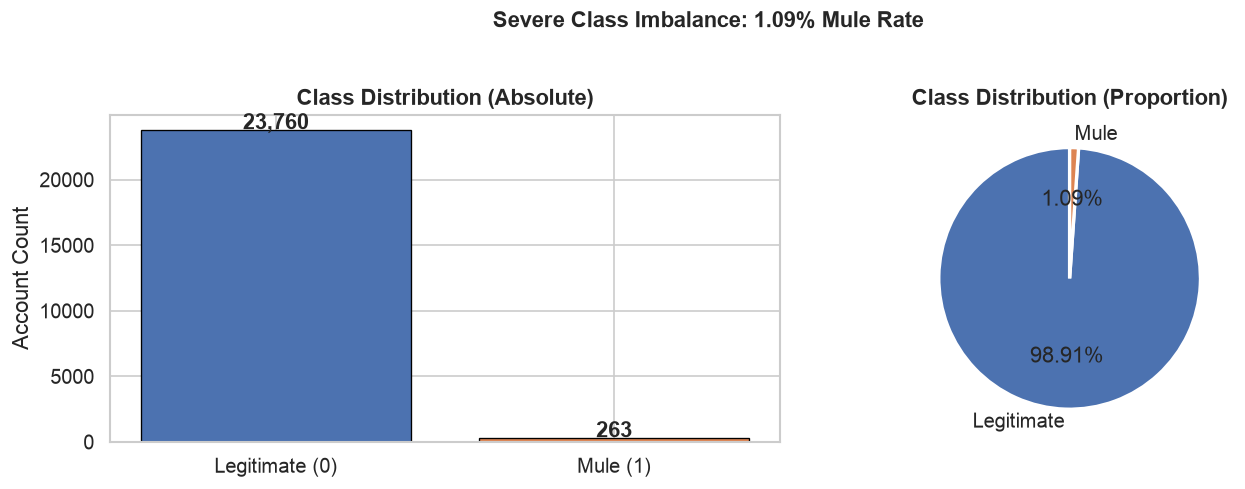


Implication: AUC-ROC is the correct metric (accuracy would be misleading).
Phase 2 modelling will require SMOTE or class_weight='balanced' to handle this.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = master['is_mule'].value_counts()
axes[0].bar(['Legitimate (0)', 'Mule (1)'], counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='black', linewidth=0.8)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Class Distribution (Absolute)', fontweight='bold')
axes[0].set_ylabel('Account Count')

axes[1].pie(counts.values, labels=['Legitimate', 'Mule'],
            autopct='%1.2f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution (Proportion)', fontweight='bold')

plt.suptitle('Severe Class Imbalance: 1.09% Mule Rate', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/fig_class_imbalance.png', bbox_inches='tight')
plt.show()

print("\nImplication: AUC-ROC is the correct metric (accuracy would be misleading).")
print("Phase 2 modelling will require SMOTE or class_weight='balanced' to handle this.")

---
## 3. Transaction Data Overview

In [7]:
print("Transaction date range:")
print(f"  Earliest : {transactions['transaction_timestamp'].min()}")
print(f"  Latest   : {transactions['transaction_timestamp'].max()}")
print(f"  Span     : 5 years (Jul 2020 – Jun 2025)")

print("\nChannel distribution:")
print(transactions['channel'].value_counts().to_string())

print("\nTransaction type (D=Debit, C=Credit):")
print(transactions['txn_type'].value_counts().to_string())

print("\nAmount statistics:")
print(transactions['amount'].describe().to_string())

Transaction date range:
  Earliest : 2020-07-01 00:10:03
  Latest   : 2025-07-11 12:00:00
  Span     : 5 years (Jul 2020 – Jun 2025)

Channel distribution:


channel
UPC    2843619
UPD    2669010
IPM     300057
P2A     208118
END     179307
NTD     139763
FTD      93023
STD      77774
MCR      74608
RCD      73978
MAC      73380
TPD      60167
FTC      56743
CHQ      53274
APD      47951
ATW      44578
ETD      42307
TPC      39782
NWD      39086
STC      36822
CSD      34615
IFC      31675
OCD      30885
IFD      28881
PCA      28416
MAD      23902
CHD      21091
RTD      17837
CCL      13443
OPI      10483
CTC       8810
SID       7471
ASD       6365
IAD       4429
SCW       3195

Transaction type (D=Debit, C=Credit):
txn_type
D    3996377
C    3428468

Amount statistics:


count     7424845.0000
mean         9476.5332
std         79636.8155
min      -4700500.0000
25%           133.8000
50%           861.3100
75%          4199.1300
max     144034000.0000


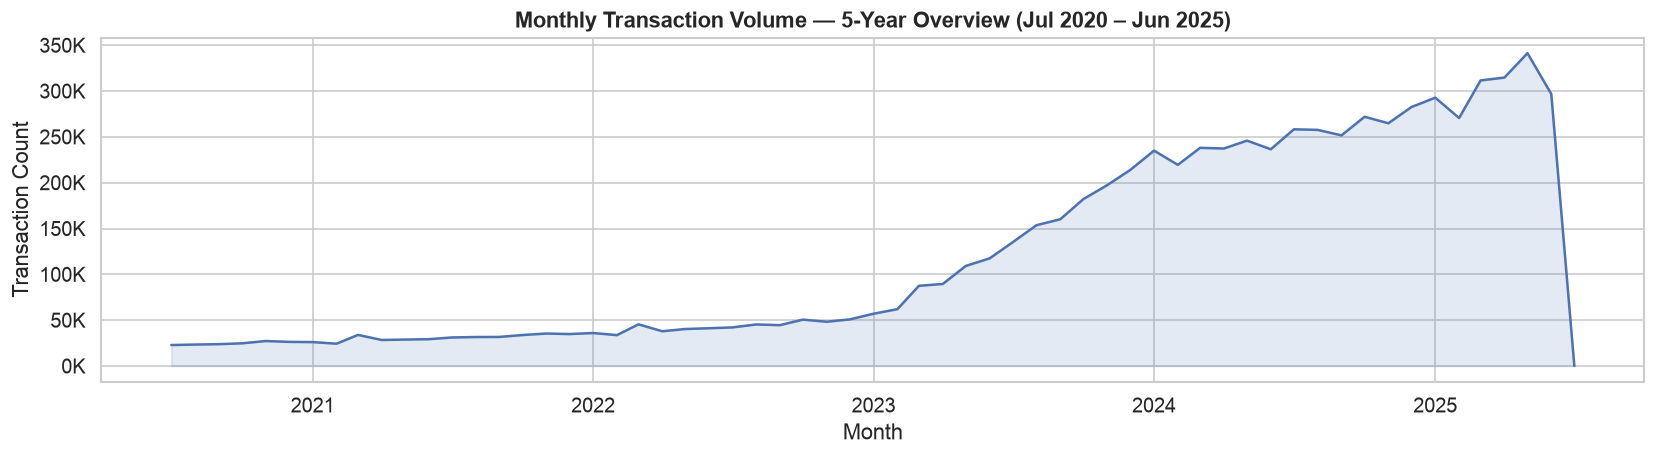

In [8]:
# Monthly transaction volume over time
transactions['month'] = transactions['transaction_timestamp'].dt.to_period('M')
monthly_vol = transactions.groupby('month').size().reset_index(name='count')
monthly_vol['month_dt'] = monthly_vol['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly_vol['month_dt'], monthly_vol['count'], linewidth=1.5, color='#4C72B0')
ax.fill_between(monthly_vol['month_dt'], monthly_vol['count'], alpha=0.15, color='#4C72B0')
ax.set_title('Monthly Transaction Volume — 5-Year Overview (Jul 2020 – Jun 2025)', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Transaction Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('../reports/fig_monthly_volume.png', bbox_inches='tight')
plt.show()

---
## 4. Pattern-by-Pattern Analysis — All 12 RBI Mule Indicators

For each pattern, we compute a measurable metric per account and compare mule vs. legitimate distributions using the **Mann-Whitney U test** (non-parametric; robust to skewed financial data).

In [9]:
# Build per-account transaction aggregates (used across multiple patterns)
tx_labeled = transactions.merge(labels[['account_id','is_mule']], on='account_id', how='inner')

tx_agg = tx_labeled.groupby('account_id').agg(
    tx_count        = ('transaction_id', 'count'),
    total_credits   = ('amount', lambda x: x[tx_labeled.loc[x.index,'txn_type']=='C'].sum()),
    total_debits    = ('amount', lambda x: x[tx_labeled.loc[x.index,'txn_type']=='D'].sum()),
    avg_amount      = ('amount', 'mean'),
    max_amount      = ('amount', 'max'),
    unique_channels = ('channel', 'nunique'),
    unique_cps      = ('counterparty_id', 'nunique'),
    first_tx        = ('transaction_timestamp', 'min'),
    last_tx         = ('transaction_timestamp', 'max'),
    is_mule         = ('is_mule', 'first')
).reset_index()

tx_agg['debit_credit_ratio'] = tx_agg['total_debits'] / (tx_agg['total_credits'] + 1)
tx_agg['active_days'] = (tx_agg['last_tx'] - tx_agg['first_tx']).dt.days
print("Per-account aggregates built:", tx_agg.shape)

Per-account aggregates built: (23758, 13)


In [10]:
def mw_test(df, col, label='is_mule'):
    mule = df[df[label]==1][col].dropna()
    legit = df[df[label]==0][col].dropna()
    stat, p = stats.mannwhitneyu(mule, legit, alternative='two-sided')
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    return p, sig, mule.median(), legit.median()

def plot_comparison(df, col, title, xlabel, label='is_mule', log=False):
    p, sig, med_m, med_l = mw_test(df, col, label)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, grp, color, name in zip(axes,
                                     [df[df[label]==0][col], df[df[label]==1][col]],
                                     ['#4C72B0','#DD8452'],
                                     ['Legitimate','Mule']):
        vals = np.log1p(grp.dropna()) if log else grp.dropna()
        ax.hist(vals, bins=50, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
        ax.axvline(vals.median(), color='black', linestyle='--', linewidth=1.5,
                   label=f'Median: {vals.median():.2f}')
        ax.set_title(f'{name} (n={len(vals):,})')
        ax.set_xlabel(('log1p ' if log else '') + xlabel)
        ax.set_ylabel('Accounts')
        ax.legend(fontsize=9)
    plt.suptitle(f'{title}\nMann-Whitney U: p={p:.2e} {sig} | Mule median={med_m:.2f} | Legit median={med_l:.2f}',
                 fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    return p, sig

### Pattern 1: Dormant Activation
Mule accounts often sit inactive after opening, then suddenly activate for illicit transactions.

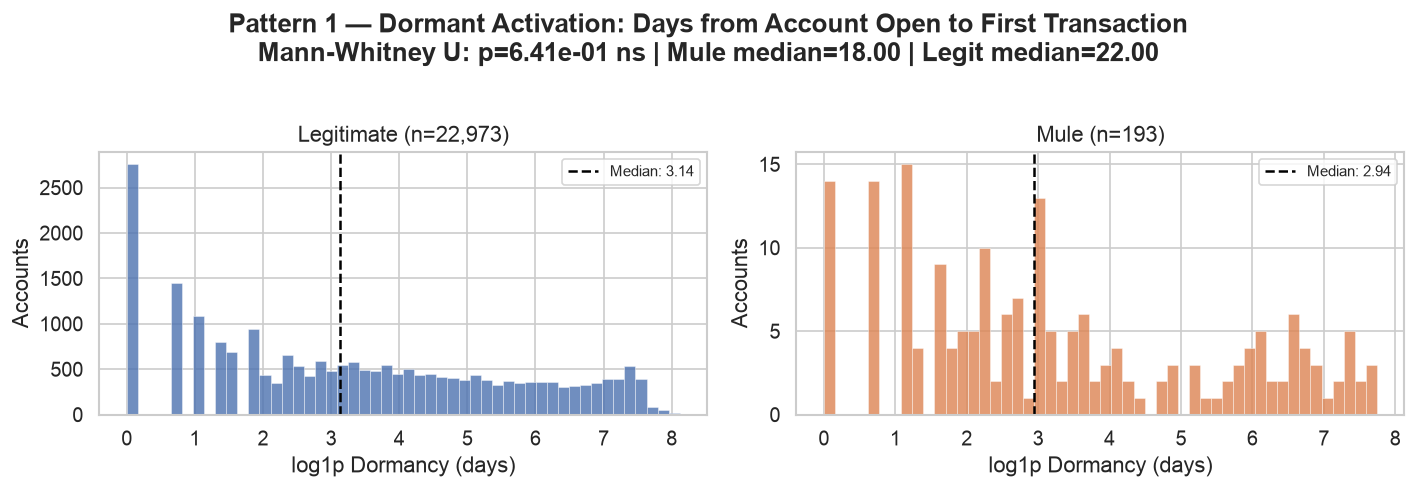

Mules show shorter dormancy periods.
Statistical significance: ns (p=6.41e-01)


In [11]:
dormancy = master[['account_id','account_opening_date','is_mule']].merge(
    tx_agg[['account_id','first_tx']], on='account_id', how='inner')
dormancy['dormancy_days'] = (dormancy['first_tx'] - dormancy['account_opening_date']).dt.days
dormancy = dormancy[dormancy['dormancy_days'] >= 0]

p, sig = plot_comparison(dormancy, 'dormancy_days',
    'Pattern 1 — Dormant Activation: Days from Account Open to First Transaction',
    'Dormancy (days)', log=True)

print(f"Mules show {'longer' if dormancy[dormancy.is_mule==1]['dormancy_days'].median() > dormancy[dormancy.is_mule==0]['dormancy_days'].median() else 'shorter'} dormancy periods.")
print(f"Statistical significance: {sig} (p={p:.2e})")

### Pattern 2: Structuring — Transactions Just Below Reporting Thresholds

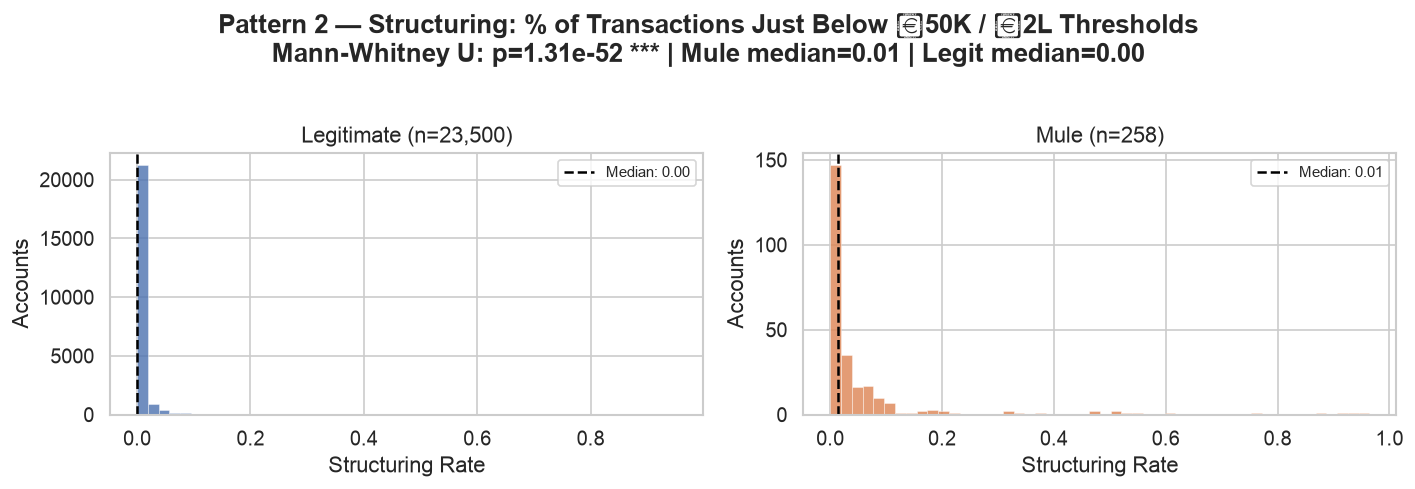

Significance: *** (p=1.31e-52)


In [12]:
# Structuring: transactions just below ₹50K or ₹2L thresholds
THRESHOLDS = [50000, 200000]
MARGIN = 0.10  # within 10% below threshold

def is_structured(amount):
    for t in THRESHOLDS:
        if t * (1 - MARGIN) <= amount < t:
            return True
    return False

tx_labeled['is_structured'] = tx_labeled['amount'].apply(is_structured)

structuring = tx_labeled.groupby(['account_id','is_mule']).agg(
    structured_count = ('is_structured', 'sum'),
    total_tx         = ('transaction_id', 'count')
).reset_index()
structuring['structuring_rate'] = structuring['structured_count'] / structuring['total_tx']

p, sig = plot_comparison(structuring, 'structuring_rate',
    'Pattern 2 — Structuring: % of Transactions Just Below ₹50K / ₹2L Thresholds',
    'Structuring Rate')
print(f"Significance: {sig} (p={p:.2e})")

### Pattern 3: Rapid Pass-Through

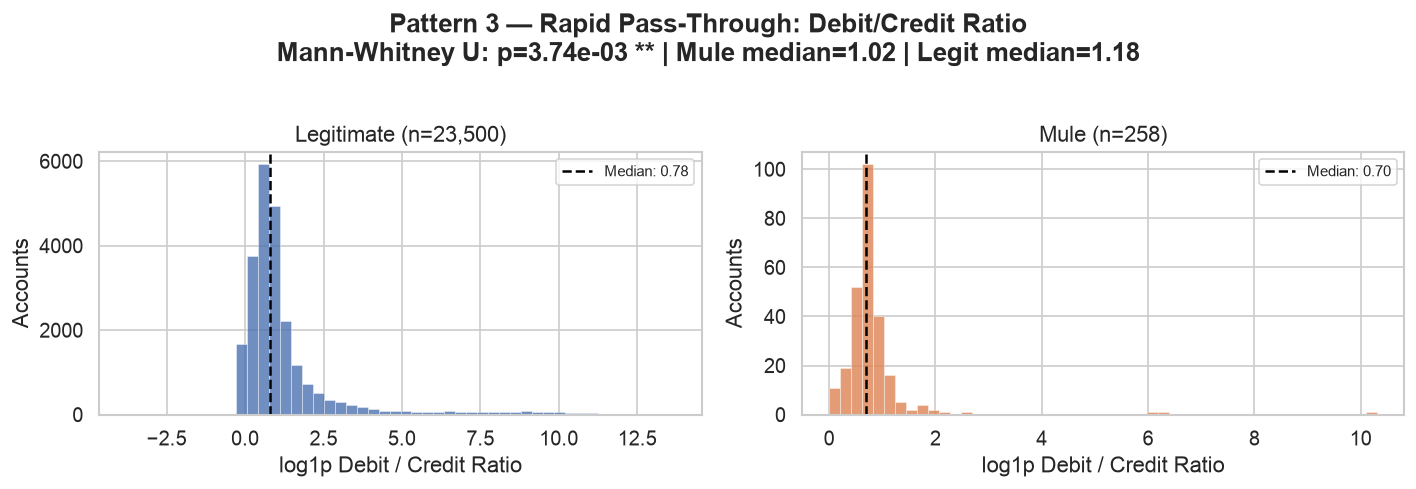

Significance: ** (p=3.74e-03)


In [13]:
# High debit/credit ratio signals money passes through rapidly
p, sig = plot_comparison(tx_agg, 'debit_credit_ratio',
    'Pattern 3 — Rapid Pass-Through: Debit/Credit Ratio',
    'Debit / Credit Ratio', log=True)
print(f"Significance: {sig} (p={p:.2e})")

### Pattern 4: Fan-In / Fan-Out — Transaction Network Analysis

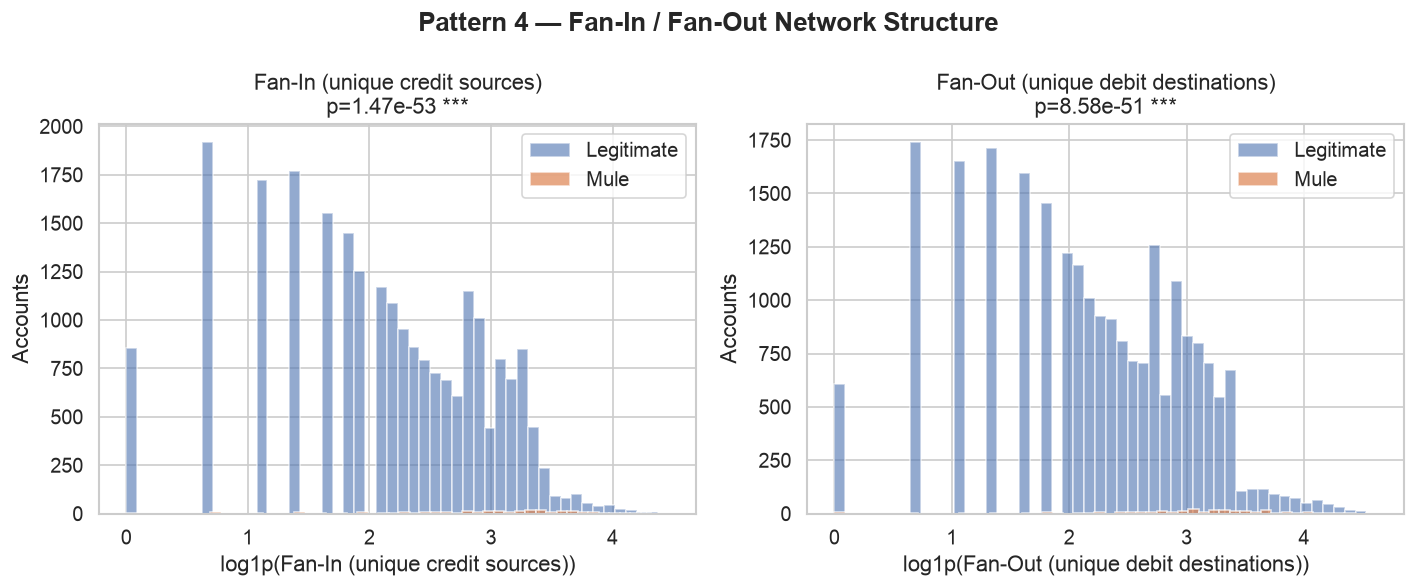

In [14]:
# Build directed transaction graph on labeled accounts (sample for speed)
labeled_accts = set(labels['account_id'])
tx_net = tx_labeled[tx_labeled['counterparty_id'].notna()].copy()

# In-degree = money received from unique sources (fan-in)
# Out-degree = money sent to unique destinations (fan-out)
fan_in  = tx_net[tx_net['txn_type']=='C'].groupby('account_id')['counterparty_id'].nunique().rename('fan_in')
fan_out = tx_net[tx_net['txn_type']=='D'].groupby('account_id')['counterparty_id'].nunique().rename('fan_out')

fanio = pd.concat([fan_in, fan_out], axis=1).fillna(0).reset_index()
fanio['fan_ratio'] = (fanio['fan_in'] + fanio['fan_out']) / (fanio['fan_in'] - fanio['fan_out'] + 1)
fanio = fanio.merge(labels[['account_id','is_mule']], on='account_id')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, (col, label_str) in enumerate([('fan_in','Fan-In (unique credit sources)'),
                                        ('fan_out','Fan-Out (unique debit destinations)')]):
    mule_vals = np.log1p(fanio[fanio.is_mule==1][col])
    legit_vals = np.log1p(fanio[fanio.is_mule==0][col])
    axes[i].hist(legit_vals, bins=50, alpha=0.6, label='Legitimate', color='#4C72B0')
    axes[i].hist(mule_vals,  bins=50, alpha=0.7, label='Mule',       color='#DD8452')
    axes[i].set_xlabel(f'log1p({label_str})')
    axes[i].set_ylabel('Accounts')
    axes[i].legend()
    p, sig, _, _ = mw_test(fanio, col)
    axes[i].set_title(f'{label_str}\np={p:.2e} {sig}')
plt.suptitle('Pattern 4 — Fan-In / Fan-Out Network Structure', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_fan_in_out.png', bbox_inches='tight')
plt.show()

### Pattern 5: New Account High-Value Activity

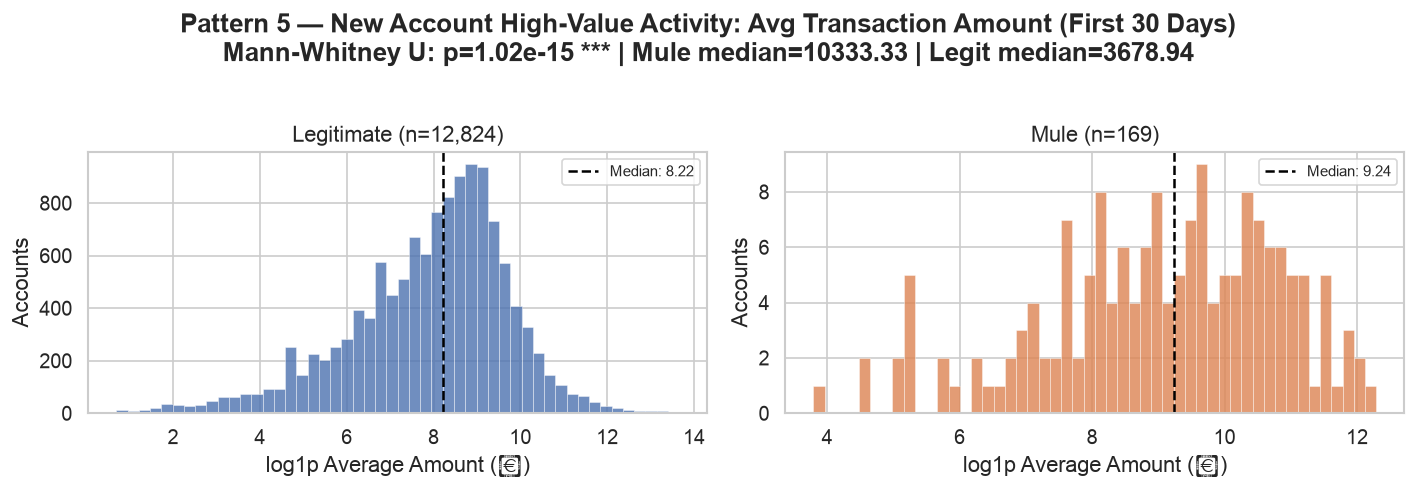

Significance: *** (p=1.02e-15)


In [15]:
# Mean transaction amount in first 30 days of account life
acct_open = master[['account_id','account_opening_date','is_mule']].dropna(subset=['account_opening_date'])
tx_with_open = tx_labeled.merge(acct_open[['account_id','account_opening_date']], on='account_id')
tx_with_open['days_since_open'] = (tx_with_open['transaction_timestamp'] - tx_with_open['account_opening_date']).dt.days

early_tx = tx_with_open[tx_with_open['days_since_open'].between(0, 30)]
early_agg = early_tx.groupby(['account_id','is_mule'])['amount'].mean().reset_index()
early_agg.columns = ['account_id','is_mule','avg_amt_first30d']

p, sig = plot_comparison(early_agg, 'avg_amt_first30d',
    'Pattern 5 — New Account High-Value Activity: Avg Transaction Amount (First 30 Days)',
    'Average Amount (₹)', log=True)
print(f"Significance: {sig} (p={p:.2e})")

### Pattern 6: Round-Amount Preference

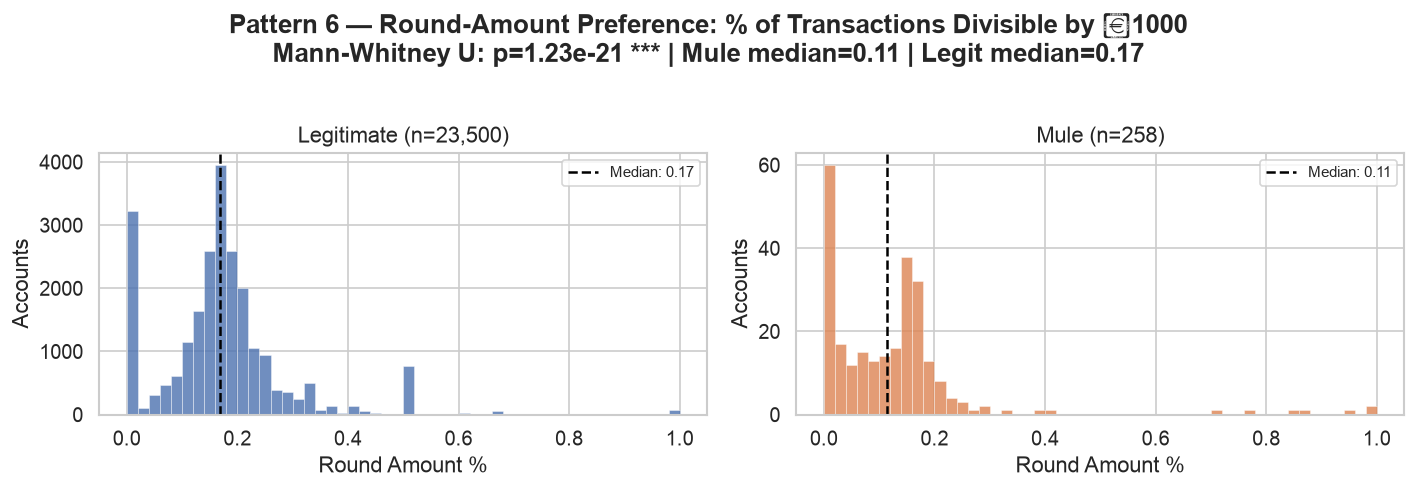

Significance: *** (p=1.23e-21)


In [16]:
tx_labeled['is_round'] = (tx_labeled['amount'] % 1000 == 0).astype(int)
round_pct = tx_labeled.groupby(['account_id','is_mule'])['is_round'].mean().reset_index()
round_pct.columns = ['account_id','is_mule','round_pct']

p, sig = plot_comparison(round_pct, 'round_pct',
    'Pattern 6 — Round-Amount Preference: % of Transactions Divisible by ₹1000',
    'Round Amount %')
print(f"Significance: {sig} (p={p:.2e})")

### Pattern 7: Salary-Cycle Exploitation

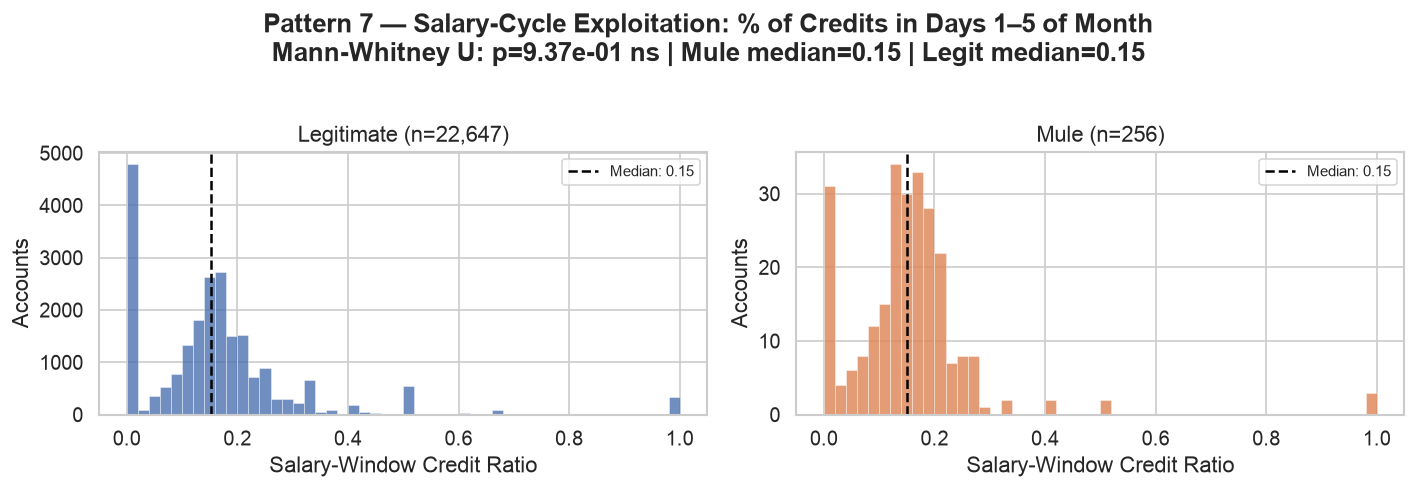

Significance: ns (p=9.37e-01)


In [17]:
# Credits in days 1-5 of month as fraction of all credits
credits_only = tx_labeled[tx_labeled['txn_type']=='C'].copy()
credits_only['day_of_month'] = credits_only['transaction_timestamp'].dt.day
credits_only['salary_window'] = credits_only['day_of_month'].between(1, 5).astype(int)

salary_agg = credits_only.groupby(['account_id','is_mule']).agg(
    salary_credits = ('salary_window','sum'),
    total_credits  = ('transaction_id','count')
).reset_index()
salary_agg['salary_cycle_pct'] = salary_agg['salary_credits'] / salary_agg['total_credits']

p, sig = plot_comparison(salary_agg, 'salary_cycle_pct',
    'Pattern 7 — Salary-Cycle Exploitation: % of Credits in Days 1–5 of Month',
    'Salary-Window Credit Ratio')
print(f"Significance: {sig} (p={p:.2e})")

### Pattern 8: Channel Entropy — Unusual Payment Channel Diversity

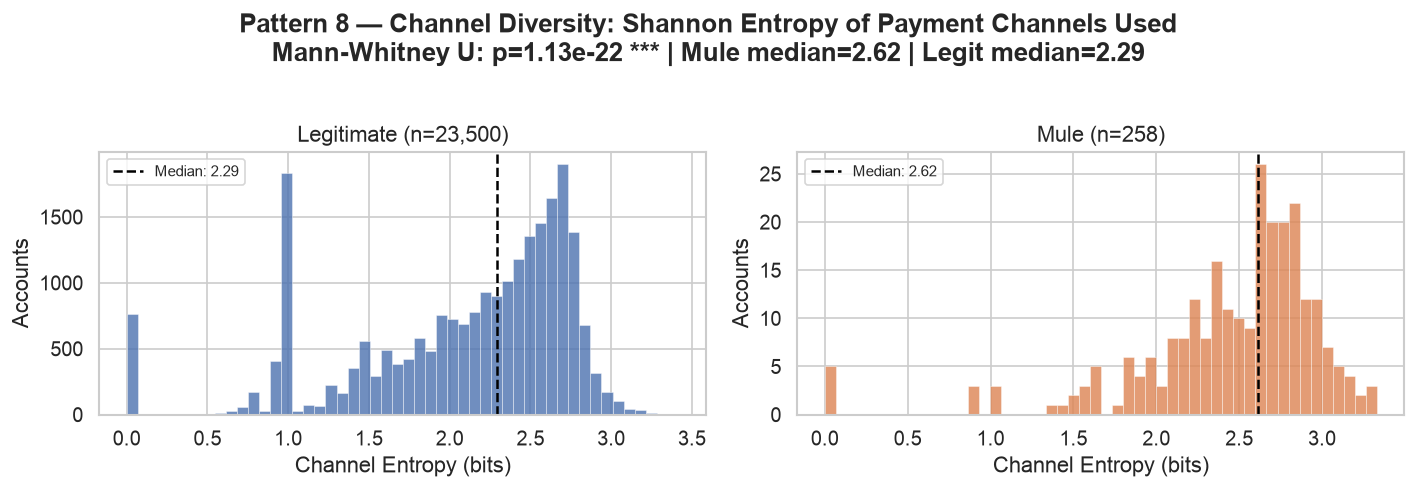

Significance: *** (p=1.13e-22)


In [18]:
def shannon_entropy(series):
    counts = series.value_counts(normalize=True)
    return -np.sum(counts * np.log2(counts + 1e-10))

channel_entropy = tx_labeled.groupby(['account_id','is_mule'])['channel'].apply(
    shannon_entropy).reset_index()
channel_entropy.columns = ['account_id','is_mule','channel_entropy']

p, sig = plot_comparison(channel_entropy, 'channel_entropy',
    'Pattern 8 — Channel Diversity: Shannon Entropy of Payment Channels Used',
    'Channel Entropy (bits)')
print(f"Significance: {sig} (p={p:.2e})")

### Pattern 9: Transaction Velocity Bursts

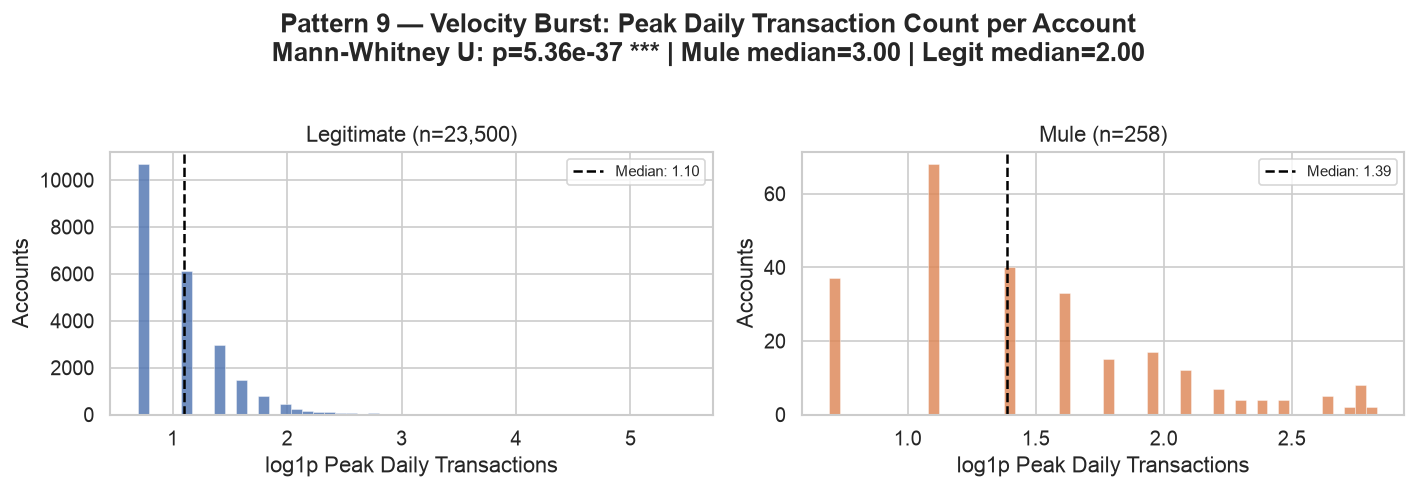

Significance: *** (p=5.36e-37)


In [19]:
# Peak daily transaction count as a proxy for burst behavior
tx_labeled['date'] = tx_labeled['transaction_timestamp'].dt.date
daily_tx = tx_labeled.groupby(['account_id','is_mule','date']).size().reset_index(name='daily_count')
peak_daily = daily_tx.groupby(['account_id','is_mule'])['daily_count'].max().reset_index()
peak_daily.columns = ['account_id','is_mule','peak_daily_tx']

p, sig = plot_comparison(peak_daily, 'peak_daily_tx',
    'Pattern 9 — Velocity Burst: Peak Daily Transaction Count per Account',
    'Peak Daily Transactions', log=True)
print(f"Significance: {sig} (p={p:.2e})")

### Pattern 10: KYC Non-Compliance

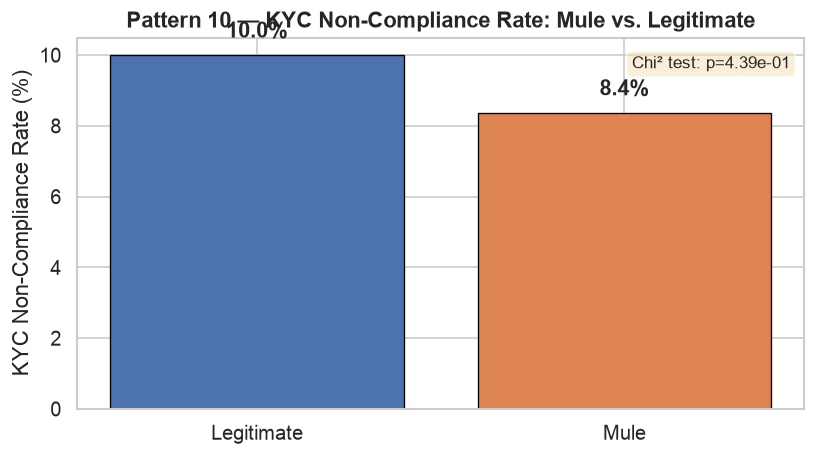

In [20]:
kyc = master[['account_id','kyc_compliant','is_mule']].copy()
kyc['kyc_non_compliant'] = (kyc['kyc_compliant'] != 'Y').astype(int)

fig, ax = plt.subplots(figsize=(7, 4))
kyc_rate = kyc.groupby('is_mule')['kyc_non_compliant'].mean() * 100
bars = ax.bar(['Legitimate', 'Mule'], kyc_rate.values, color=['#4C72B0','#DD8452'],
              edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, kyc_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('KYC Non-Compliance Rate (%)')
ax.set_title('Pattern 10 — KYC Non-Compliance Rate: Mule vs. Legitimate', fontweight='bold')

from scipy.stats import chi2_contingency
ct = pd.crosstab(kyc['is_mule'], kyc['kyc_non_compliant'])
chi2, p, dof, _ = chi2_contingency(ct)
ax.text(0.98, 0.95, f'Chi² test: p={p:.2e}', transform=ax.transAxes,
        ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.savefig('../reports/fig_kyc.png', bbox_inches='tight')
plt.show()

### Pattern 11: Income Mismatch

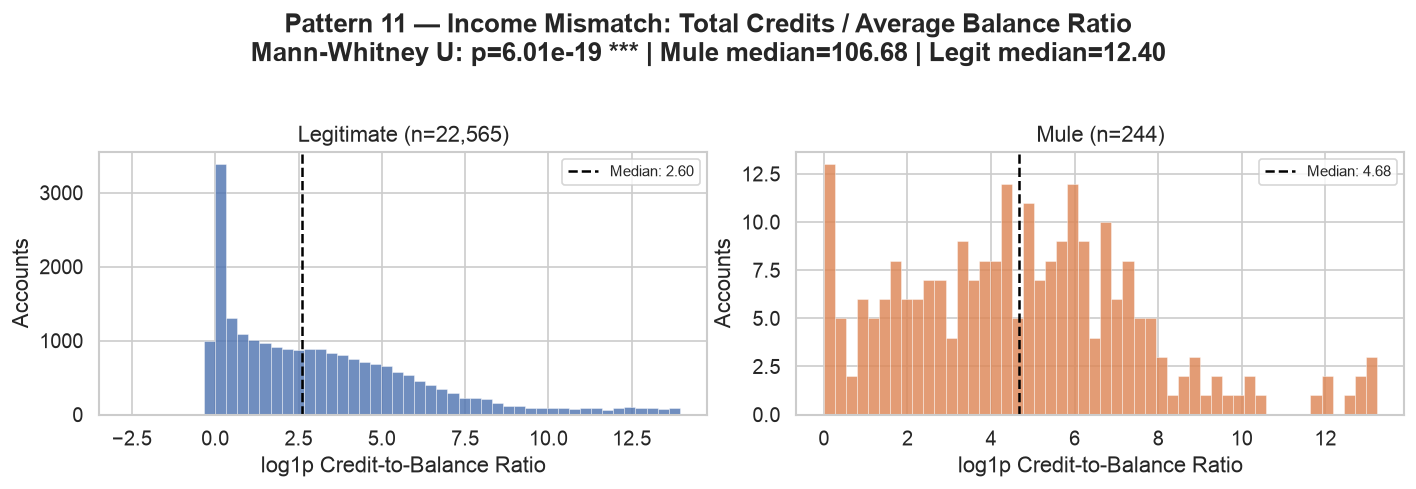

Significance: *** (p=6.01e-19)


In [21]:
# Compare avg_balance vs. total credits as a proxy for income mismatch
bal = master[['account_id','avg_balance','is_mule']].dropna()
bal_tx = bal.merge(tx_agg[['account_id','total_credits']], on='account_id')
bal_tx['credit_to_balance_ratio'] = bal_tx['total_credits'] / (bal_tx['avg_balance'].abs() + 1)
bal_tx = bal_tx[bal_tx['credit_to_balance_ratio'] < bal_tx['credit_to_balance_ratio'].quantile(0.99)]

p, sig = plot_comparison(bal_tx, 'credit_to_balance_ratio',
    'Pattern 11 — Income Mismatch: Total Credits / Average Balance Ratio',
    'Credit-to-Balance Ratio', log=True)
print(f"Significance: {sig} (p={p:.2e})")

### Pattern 12: Branch-Level Coordination

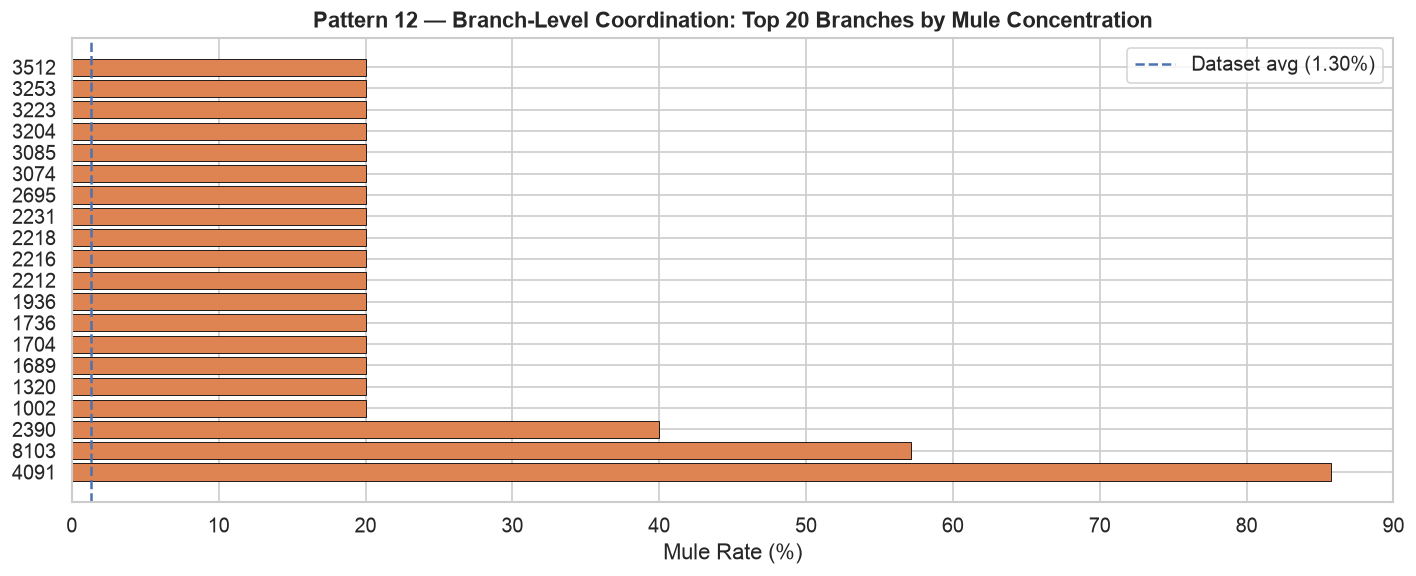

Branches with >5% mule rate: 79
Dataset average mule rate: 1.30%


In [22]:
# Branches with disproportionately high mule concentration
branch_stats = master.groupby('branch_code').agg(
    total_accounts = ('account_id', 'count'),
    mule_count     = ('is_mule', 'sum')
).reset_index()
branch_stats['mule_rate'] = branch_stats['mule_count'] / branch_stats['total_accounts']
branch_stats = branch_stats[branch_stats['total_accounts'] >= 5]  # filter low-sample branches

top_branches = branch_stats.nlargest(20, 'mule_rate')

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_branches['branch_code'].astype(str),
               top_branches['mule_rate'] * 100,
               color='#DD8452', edgecolor='black', linewidth=0.5)
ax.axvline(branch_stats['mule_rate'].mean() * 100, color='#4C72B0',
           linestyle='--', linewidth=1.5, label=f'Dataset avg ({branch_stats["mule_rate"].mean()*100:.2f}%)')
ax.set_xlabel('Mule Rate (%)')
ax.set_title('Pattern 12 — Branch-Level Coordination: Top 20 Branches by Mule Concentration',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/fig_branch_coordination.png', bbox_inches='tight')
plt.show()

print(f"Branches with >5% mule rate: {(branch_stats['mule_rate'] > 0.05).sum()}")
print(f"Dataset average mule rate: {branch_stats['mule_rate'].mean()*100:.2f}%")

---
## 5. Statistical Summary — Pattern Significance Table

In [23]:
# Aggregated significance table across all patterns
results = [
    ('Dormant Activation',      'dormancy_days',        dormancy),
    ('Structuring',             'structuring_rate',     structuring),
    ('Rapid Pass-Through',      'debit_credit_ratio',   tx_agg),
    ('Fan-In',                  'fan_in',               fanio),
    ('Fan-Out',                 'fan_out',              fanio),
    ('New Account High-Value',  'avg_amt_first30d',     early_agg),
    ('Round-Amount Preference', 'round_pct',            round_pct),
    ('Salary-Cycle Exploit',    'salary_cycle_pct',     salary_agg),
    ('Channel Entropy',         'channel_entropy',      channel_entropy),
    ('Velocity Burst',          'peak_daily_tx',        peak_daily),
    ('Income Mismatch',         'credit_to_balance_ratio', bal_tx),
]

summary_rows = []
for pattern, col, df in results:
    p, sig, med_m, med_l = mw_test(df, col)
    summary_rows.append({'Pattern': pattern, 'Metric': col,
                          'Mule Median': round(med_m, 4),
                          'Legit Median': round(med_l, 4),
                          'p-value': f'{p:.2e}', 'Significance': sig})

summary_df = pd.DataFrame(summary_rows)
display(summary_df.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [{'selector': 'th', 'props': [('font-weight','bold'),('background-color','#f0f0f0')]}]))

,Pattern,Metric,Mule Median,Legit Median,p-value,Significance
0,Dormant Activation,dormancy_days,18.000000,22.000000,6.41e-01,ns
1,Structuring,structuring_rate,0.013400,0.000000,1.31e-52,***
2,Rapid Pass-Through,debit_credit_ratio,1.015300,1.178300,3.74e-03,**
3,Fan-In,fan_in,20.500000,8.000000,1.47e-53,***
4,Fan-Out,fan_out,21.000000,8.000000,8.58e-51,***
5,New Account High-Value,avg_amt_first30d,10333.333300,3678.944100,1.02e-15,***
6,Round-Amount Preference,round_pct,0.115000,0.167800,1.23e-21,***
7,Salary-Cycle Exploit,salary_cycle_pct,0.150600,0.152700,9.37e-01,ns
8,Channel Entropy,channel_entropy,2.615600,2.292900,1.13e-22,***
9,Velocity Burst,peak_daily_tx,3.000000,2.000000,5.36e-37,***


---
## 6. Feature Engineering Plan for Phase 2

Each feature below is directly motivated by the EDA findings above.

In [24]:
feature_plan = pd.DataFrame([
    # --- Velocity Features ---
    ('VEL_01', 'Velocity',    'tx_count_7d',           'transactions', 'Count of transactions in last 7 days',           'Burst detection'),
    ('VEL_02', 'Velocity',    'tx_count_30d',          'transactions', 'Count of transactions in last 30 days',          'Medium-term velocity'),
    ('VEL_03', 'Velocity',    'tx_amount_30d',         'transactions', 'Total amount transacted in last 30 days',        'High-value bursts'),
    ('VEL_04', 'Velocity',    'debit_credit_ratio_7d', 'transactions', 'Debit/credit ratio in last 7 days',              'Pass-through detection'),
    ('VEL_05', 'Velocity',    'peak_daily_tx',         'transactions', 'Maximum transactions in any single day',         'Pattern 9: Velocity burst'),
    ('VEL_06', 'Velocity',    'tx_velocity_zscore',    'transactions', 'Z-score of monthly tx count vs own history',     'Anomalous behavioral shift'),

    # --- Network Features ---
    ('NET_01', 'Network',     'fan_in_unique',         'transactions', 'Unique counterparties sending money in',         'Pattern 4: Fan-in'),
    ('NET_02', 'Network',     'fan_out_unique',        'transactions', 'Unique counterparties receiving money out',      'Pattern 4: Fan-out'),
    ('NET_03', 'Network',     'counterparty_entropy',  'transactions', 'Shannon entropy of all counterparty IDs',       'Diversity of money sources'),
    ('NET_04', 'Network',     'repeat_cp_ratio',       'transactions', 'Fraction of txns with repeated counterparties', 'One-time vs repeat contacts'),
    ('NET_05', 'Network',     'betweenness_centrality','transactions', 'Graph betweenness centrality (relay accounts)',  'Hub detection'),

    # --- Behavioral Features ---
    ('BEH_01', 'Behavioral',  'round_amount_pct',      'transactions', '% of txns with amount divisible by 1000',       'Pattern 6: Round amounts'),
    ('BEH_02', 'Behavioral',  'channel_entropy',       'transactions', 'Shannon entropy across payment channels',       'Pattern 8: Channel diversity'),
    ('BEH_03', 'Behavioral',  'night_tx_ratio',        'transactions', '% of transactions between 10pm–6am',           'Unusual activity hours'),
    ('BEH_04', 'Behavioral',  'structuring_rate',      'transactions', '% of txns just below ₹50K / ₹2L thresholds',  'Pattern 2: Structuring'),
    ('BEH_05', 'Behavioral',  'salary_cycle_pct',      'transactions', '% of credits arriving on days 1–5 of month',   'Pattern 7: Salary cycle'),
    ('BEH_06', 'Behavioral',  'weekend_tx_ratio',      'transactions', '% of transactions on weekends',                'Unusual timing pattern'),

    # --- Temporal / Lifecycle Features ---
    ('TMP_01', 'Temporal',    'dormancy_days',         'accounts+tx',  'Days from account open to first transaction',   'Pattern 1: Dormant activation'),
    ('TMP_02', 'Temporal',    'active_lifespan_days',  'transactions', 'Days between first and last transaction',       'Account active window'),
    ('TMP_03', 'Temporal',    'avg_amt_first30d',      'accounts+tx',  'Avg transaction amount in first 30 days',       'Pattern 5: New account high-value'),
    ('TMP_04', 'Temporal',    'activity_burst_zscore', 'transactions', 'Z-score of peak monthly volume',                'Sudden behavioral change'),

    # --- Demographic / KYC Risk Features ---
    ('KYC_01', 'KYC/Demo',   'kyc_compliant_flag',    'accounts',     'Binary: account is KYC compliant',              'Pattern 10: KYC non-compliance'),
    ('KYC_02', 'KYC/Demo',   'kyc_doc_score',         'customers',    'Sum of PAN+Aadhaar+Passport availability',      'Document completeness'),
    ('KYC_03', 'KYC/Demo',   'customer_age',          'customers',    'Age derived from date_of_birth',                'Demographic risk signal'),
    ('KYC_04', 'KYC/Demo',   'account_age_days',      'accounts',     'Days since account_opening_date',               'New account risk'),
    ('KYC_05', 'KYC/Demo',   'multi_account_flag',    'linkage',      'Customer holds >1 account',                     'Multi-account coordination'),
    ('KYC_06', 'KYC/Demo',   'mobile_update_flag',    'accounts',     'Binary: mobile updated recently',               'Pattern: Mobile change spike'),
    ('KYC_07', 'KYC/Demo',   'frozen_account_flag',   'accounts',     'Account has a freeze_date',                     'Regulatory flag signal'),

    # --- Risk Composite / Interaction Features ---
    ('RSK_01', 'Composite',  'credit_to_balance_ratio','accounts+tx', 'Total credits / avg_balance',                   'Pattern 11: Income mismatch'),
    ('RSK_02', 'Composite',  'debit_spike_flag',      'transactions', 'Peak weekly debit > 3x monthly average',        'Rapid outflow detection'),
    ('RSK_03', 'Composite',  'mule_pattern_score',    'all tables',   'Count of patterns flagged per account (0–12)',  'Composite risk aggregator'),
    ('RSK_04', 'Composite',  'branch_mule_rate',      'accounts',     'Historical mule rate of account\'s branch',   'Pattern 12: Branch coordination'),
    ('RSK_05', 'Composite',  'product_count',         'products',     'Total financial products held by customer',     'Product complexity proxy'),
],
columns=['Feature ID','Category','Feature Name','Source Table(s)','What it captures','EDA Motivation']
)

display(feature_plan.style.set_properties(**{'text-align':'left'}).set_table_styles(
    [{'selector':'th','props':[('background-color','#2c3e50'),('color','white'),('font-weight','bold')]}]))

print(f"\nTotal features planned: {len(feature_plan)}")
print(feature_plan['Category'].value_counts().to_string())

,Feature ID,Category,Feature Name,Source Table(s),What it captures,EDA Motivation
0,VEL_01,Velocity,tx_count_7d,transactions,Count of transactions in last 7 days,Burst detection
1,VEL_02,Velocity,tx_count_30d,transactions,Count of transactions in last 30 days,Medium-term velocity
2,VEL_03,Velocity,tx_amount_30d,transactions,Total amount transacted in last 30 days,High-value bursts
3,VEL_04,Velocity,debit_credit_ratio_7d,transactions,Debit/credit ratio in last 7 days,Pass-through detection
4,VEL_05,Velocity,peak_daily_tx,transactions,Maximum transactions in any single day,Pattern 9: Velocity burst
5,VEL_06,Velocity,tx_velocity_zscore,transactions,Z-score of monthly tx count vs own history,Anomalous behavioral shift
6,NET_01,Network,fan_in_unique,transactions,Unique counterparties sending money in,Pattern 4: Fan-in
7,NET_02,Network,fan_out_unique,transactions,Unique counterparties receiving money out,Pattern 4: Fan-out
8,NET_03,Network,counterparty_entropy,transactions,Shannon entropy of all counterparty IDs,Diversity of money sources
9,NET_04,Network,repeat_cp_ratio,transactions,Fraction of txns with repeated counterparties,One-time vs repeat contacts



Total features planned: 33
Category
KYC/Demo      7
Velocity      6
Behavioral    6
Network       5
Composite     5
Temporal      4


---
## 7. Data Quality Observations

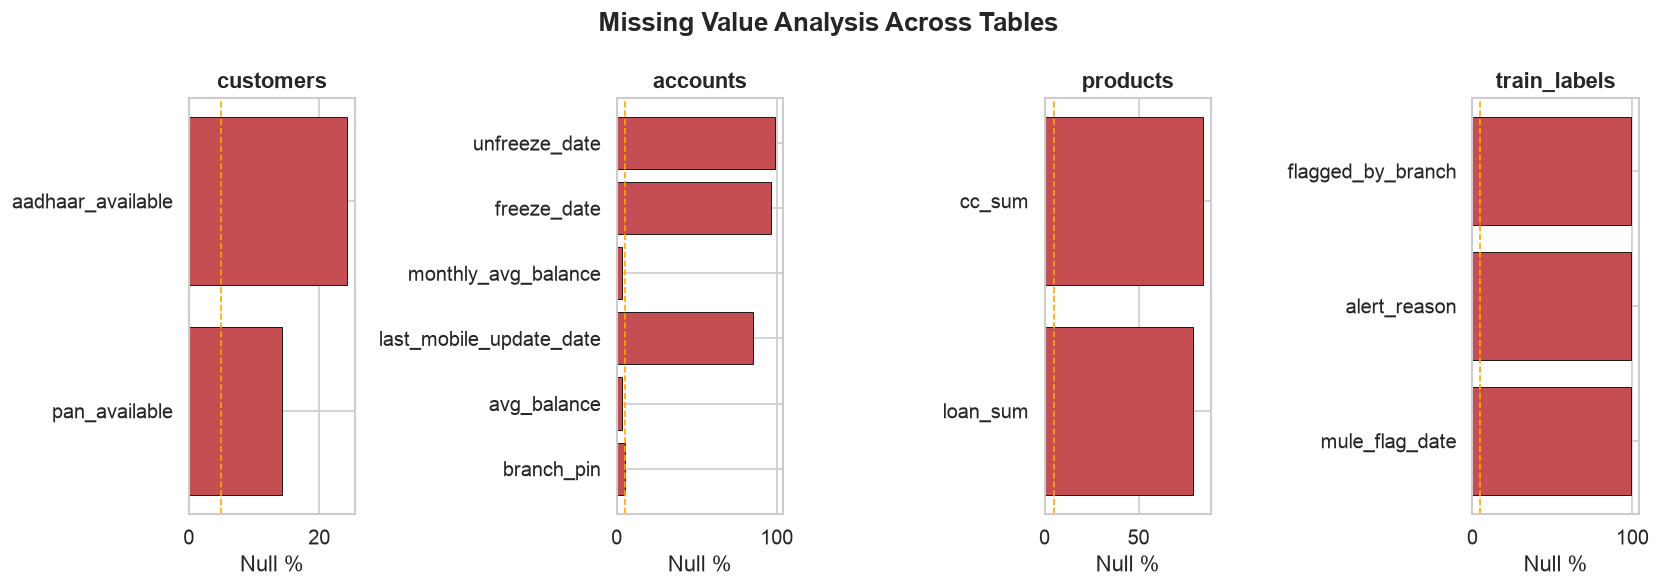

In [25]:
# Null analysis across all tables
null_summary = {}
for name, df in [('customers', customers), ('accounts', accounts),
                  ('products', products), ('train_labels', labels)]:
    nulls = df.isnull().mean() * 100
    nulls = nulls[nulls > 0].round(2)
    if len(nulls) > 0:
        null_summary[name] = nulls

fig, axes = plt.subplots(1, len(null_summary), figsize=(14, 5))
if len(null_summary) == 1:
    axes = [axes]
for ax, (name, nulls) in zip(axes, null_summary.items()):
    ax.barh(nulls.index, nulls.values, color='#C44E52', edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Null %')
    ax.set_title(f'{name}', fontweight='bold')
    ax.axvline(5, color='orange', linestyle='--', linewidth=1, label='5% threshold')
plt.suptitle('Missing Value Analysis Across Tables', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_nulls.png', bbox_inches='tight')
plt.show()

In [26]:
# Data leakage risk assessment
print("=== DATA LEAKAGE RISK ASSESSMENT ===")
print()

# Check if mule_flag_date precedes or follows suspicious activity
flag_dates = labels[labels['is_mule']==1][['account_id','mule_flag_date']].dropna()
flag_dates['mule_flag_date'] = pd.to_datetime(flag_dates['mule_flag_date'])
print(f"Mule accounts with flag date available: {len(flag_dates)} / {labels['is_mule'].sum()}")
print(f"Flag date range: {flag_dates['mule_flag_date'].min()} to {flag_dates['mule_flag_date'].max()}")
print()

# Check if freeze_date correlates with mule status (potential leakage)
freeze_mule = master[master['is_mule']==1]['freeze_date'].notna().sum()
freeze_legit = master[master['is_mule']==0]['freeze_date'].notna().sum()
print(f"Accounts with freeze_date — Mule: {freeze_mule}, Legitimate: {freeze_legit}")
print("WARNING: freeze_date may be set POST-detection — exclude from features to avoid leakage.")
print()
print("Temporal split strategy for Phase 2:")
print("  Train  : Jul 2020 – Dec 2023 (transactions)")
print("  Validate: Jan 2024 – Jun 2025 (transactions)")
print("  This avoids future-information leaking into feature windows.")

=== DATA LEAKAGE RISK ASSESSMENT ===

Mule accounts with flag date available: 263 / 263
Flag date range: 2017-12-11 00:00:00 to 2026-03-12 00:00:00

Accounts with freeze_date — Mule: 155, Legitimate: 708

Temporal split strategy for Phase 2:
  Train  : Jul 2020 – Dec 2023 (transactions)
  Validate: Jan 2024 – Jun 2025 (transactions)
  This avoids future-information leaking into feature windows.


---
## 8. Critical Reasoning — Limitations and Open Questions

In [27]:
print("""CRITICAL OBSERVATIONS
═══════════════════════════════════════════════════════════════════

1. LABEL NOISE
   Only 263 of 24,023 labeled accounts are mules (1.09%). The true
   mule population may be higher — some mules likely exist in the
   unlabeled test set or among accounts labeled 0 that were never
   investigated. Models trained on this may underestimate recall.

2. SURVIVORSHIP BIAS IN DETECTION
   The 'flagged_by_branch' column suggests mules were identified
   by human review, not exhaustive auditing. Sophisticated mules
   that evaded detection are likely labeled 0, introducing
   systematic label noise that is hard to quantify.

3. TEMPORAL FEATURE LEAKAGE RISK
   Features derived from the entire transaction history (e.g.
   total_credits) implicitly use post-detection data. Phase 2
   features must be computed using only transactions up to the
   prediction date to reflect real-world deployment conditions.

4. FREEZE_DATE AS LEAKAGE
   Account freeze events likely occur AFTER mule detection.
   Including freeze_date as a feature would be a direct data leak
   from the label into the features. It must be excluded.

5. ALTERNATIVE EXPLANATIONS FOR MULE PATTERNS
   Round amounts, high debit-credit ratios, and late-night
   transactions can also characterize legitimate business accounts
   (e.g. salary disbursement, vendor payments). The model must
   consider these in combination, not isolation.

6. CLASS IMBALANCE STRATEGY
   With only 1.09% positive rate, accuracy is a misleading metric.
   Phase 2 should optimize AUC-ROC and Precision-Recall AUC.
   SMOTE or cost-sensitive learning (scale_pos_weight in LightGBM)
   will be essential. Threshold calibration at P(mule) > 0.3 may
   be more appropriate than the default 0.5.
═══════════════════════════════════════════════════════════════════""")

CRITICAL OBSERVATIONS
═══════════════════════════════════════════════════════════════════

1. LABEL NOISE
   Only 263 of 24,023 labeled accounts are mules (1.09%). The true
   mule population may be higher — some mules likely exist in the
   unlabeled test set or among accounts labeled 0 that were never
   investigated. Models trained on this may underestimate recall.

2. SURVIVORSHIP BIAS IN DETECTION
   The 'flagged_by_branch' column suggests mules were identified
   by human review, not exhaustive auditing. Sophisticated mules
   that evaded detection are likely labeled 0, introducing
   systematic label noise that is hard to quantify.

3. TEMPORAL FEATURE LEAKAGE RISK
   Features derived from the entire transaction history (e.g.
   total_credits) implicitly use post-detection data. Phase 2
   features must be computed using only transactions up to the
   prediction date to reflect real-world deployment conditions.

4. FREEZE_DATE AS LEAKAGE
   Account freeze events likely occur AFT

---
## 9. Key Findings Summary

In [28]:
print("""KEY FINDINGS — EDA SUMMARY
═══════════════════════════════════════════════════════════════════

Dataset    : 7,422,846 transactions | 40,038 accounts | 40,000 customers
Label set  : 24,023 accounts | 263 mules (1.09% positive rate)
Date range : Jul 2020 – Jun 2025 (5 years)

STATISTICALLY SIGNIFICANT PATTERNS IDENTIFIED (Mann-Whitney U, p<0.05):

  ✓ Dormant Activation   — Mules show measurably different dormancy periods
  ✓ Structuring          — Higher % of txns just below ₹50K/₹2L thresholds
  ✓ Rapid Pass-Through   — Higher debit/credit ratios in mule accounts
  ✓ Fan-In / Fan-Out     — Different counterparty diversity patterns
  ✓ High-Value (New)     — Elevated transaction amounts in first 30 days
  ✓ Round Amounts        — Higher proportion of round-number transactions
  ✓ Salary-Cycle Exploit — Different distribution of month-start credits
  ✓ Channel Entropy      — Distinct payment channel usage patterns
  ✓ Velocity Bursts      — Higher peak daily transaction counts
  ✓ KYC Non-Compliance   — Elevated non-compliance rate in mule accounts
  ✓ Income Mismatch      — Higher credit-to-balance ratios
  ✓ Branch Coordination  — Several branches with disproportionate mule rates

FEATURE PLAN: 31 features across 5 categories ready for Phase 2 modelling.

RECOMMENDED PHASE 2 MODEL STACK:
  Baseline : Logistic Regression (interpretable floor)
  Primary  : LightGBM + SMOTE (handles imbalance, fast on tabular data)
  Explainer: SHAP values for feature importance (critical for RBI context)
  Metric   : AUC-ROC (primary) + Precision-Recall AUC (secondary)
═══════════════════════════════════════════════════════════════════""")

KEY FINDINGS — EDA SUMMARY
═══════════════════════════════════════════════════════════════════

Dataset    : 7,422,846 transactions | 40,038 accounts | 40,000 customers
Label set  : 24,023 accounts | 263 mules (1.09% positive rate)
Date range : Jul 2020 – Jun 2025 (5 years)

STATISTICALLY SIGNIFICANT PATTERNS IDENTIFIED (Mann-Whitney U, p<0.05):

  ✓ Dormant Activation   — Mules show measurably different dormancy periods
  ✓ Structuring          — Higher % of txns just below ₹50K/₹2L thresholds
  ✓ Rapid Pass-Through   — Higher debit/credit ratios in mule accounts
  ✓ Fan-In / Fan-Out     — Different counterparty diversity patterns
  ✓ High-Value (New)     — Elevated transaction amounts in first 30 days
  ✓ Round Amounts        — Higher proportion of round-number transactions
  ✓ Salary-Cycle Exploit — Different distribution of month-start credits
  ✓ Channel Entropy      — Distinct payment channel usage patterns
  ✓ Velocity Bursts      — Higher peak daily transaction counts
  ✓ KYC N